# 04. 모델링 (Modeling)

**모델 스택**: Logistic Regression (베이스라인) → Decision Tree → Random Forest → LightGBM → XGBoost  
**검증 방법**: Stratified K-Fold (k=5), SMOTE는 각 fold 내부에서 적용  
**주 평가 지표**: AUC-ROC  
**부 평가 지표**: F1-score, Precision, Recall

---
## 0. 라이브러리 & 설정

In [52]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, roc_curve
)
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('../outputs', exist_ok=True)
print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드

In [53]:
X_train = pd.read_parquet('../data/interim/X_train.parquet')
y_train = pd.read_parquet('../data/interim/y_train.parquet')['label']
X_test  = pd.read_parquet('../data/interim/X_test.parquet')
y_test  = pd.read_parquet('../data/interim/y_test.parquet')['label']

feature_cols = X_train.columns.tolist()

print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print(f'피처: {feature_cols}')
print(f'\nTrain 클래스 분포: {y_train.value_counts().to_dict()}')
print(f'Test  클래스 분포: {y_test.value_counts().to_dict()}')

X_train: (1562, 6)  X_test: (391, 6)
피처: ['avg_delay', 'total_orders', 'is_ever_delayed', 'recency_days', 'delay_trend', 'order_interval_days']

Train 클래스 분포: {1: 1516, 0: 46}
Test  클래스 분포: {1: 379, 0: 12}


---
## 2. CV 헬퍼 & SKF 설정

- SMOTE는 각 fold의 train split에만 적용 (pipeline 내부에서 처리)
- `predict_proba`가 없는 모델 대비 `decision_function` fallback 불필요 — 세 모델 모두 지원

In [54]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(pipeline, X, y, model_name):
    """Stratified K-Fold CV. 불균형 처리는 파이프라인 내 모델 파라미터에서 처리."""
    results = {'auc': [], 'f1': [], 'precision': [], 'recall': []}
    print(f'=== {model_name} — CV (k=5) ===')
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        y_pred = pipeline.predict(X_val)
        results['auc'].append(roc_auc_score(y_val, y_prob))
        results['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        results['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        results['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        print(f'  Fold {fold}: AUC={results["auc"][-1]:.4f}  F1={results["f1"][-1]:.4f}')
    print(f'  → CV AUC: {np.mean(results["auc"]):.4f} ± {np.std(results["auc"]):.4f}\n')
    return results


def eval_test(pipeline, X_test, y_test):
    """Test set 최종 평가."""
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
    return {
        'test_auc'      : roc_auc_score(y_test, y_prob),
        'test_f1'       : f1_score(y_test, y_pred, zero_division=0),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall'   : recall_score(y_test, y_pred, zero_division=0),
        'y_prob'        : y_prob,
    }

print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


---
## 3. Logistic Regression

- Pipeline: SMOTE → StandardScaler → LogisticRegression
- SMOTE로 불균형 처리

In [55]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=42,
                                   class_weight='balanced')),
])

lr_cv = run_cv(lr_pipe, X_train, y_train, 'Logistic Regression')

=== Logistic Regression — CV (k=5) ===
  Fold 1: AUC=0.6897  F1=0.8185
  Fold 2: AUC=0.7294  F1=0.8333
  Fold 3: AUC=0.6670  F1=0.8008
  Fold 4: AUC=0.5959  F1=0.8497
  Fold 5: AUC=0.7528  F1=0.8403
  → CV AUC: 0.6870 ± 0.0545



In [56]:
# 전체 train으로 최종 학습 후 test 평가
lr_pipe.fit(X_train, y_train)
lr_test = eval_test(lr_pipe, X_test, y_test)

print('=== Logistic Regression — Test 결과 ===')
for k, v in lr_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

=== Logistic Regression — Test 결과 ===
  test_auc: 0.8096
  test_f1: 0.8155
  test_precision: 0.9887
  test_recall: 0.6939


---
## 4. LightGBM

In [57]:
lgb_pipe = Pipeline([
    ('lgb', lgb.LGBMClassifier(n_estimators=300, random_state=42,
                                 n_jobs=-1, verbose=-1,
                                 class_weight='balanced')),
])

lgb_cv = run_cv(lgb_pipe, X_train, y_train, 'LightGBM')

=== LightGBM — CV (k=5) ===
  Fold 1: AUC=0.7445  F1=0.9838
  Fold 2: AUC=0.6571  F1=0.9771
  Fold 3: AUC=0.5233  F1=0.9853
  Fold 4: AUC=0.4877  F1=0.9821
  Fold 5: AUC=0.6494  F1=0.9804
  → CV AUC: 0.6124 ± 0.0941



In [58]:
lgb_pipe.fit(X_train, y_train)
lgb_test = eval_test(lgb_pipe, X_test, y_test)

print('=== LightGBM — Test 결과 ===')
for k, v in lgb_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

=== LightGBM — Test 결과 ===
  test_auc: 0.6185
  test_f1: 0.9778
  test_precision: 0.9689
  test_recall: 0.9868


---
## 5. XGBoost

In [59]:
# scale_pos_weight: label=1(이탈)이 다수 → 소수 클래스(유지, label=0) 균형 보정
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.values)
spw = float(cw[1])  # label=1의 가중치 (다수 클래스 → < 1)
print(f'scale_pos_weight: {spw:.4f}  (유지 가중치: {cw[0]:.4f})')

xgb_pipe = Pipeline([
    ('xgb', xgb.XGBClassifier(n_estimators=300, random_state=42,
                                 n_jobs=-1, verbosity=0, eval_metric='auc',
                                 scale_pos_weight=spw)),
])

xgb_cv = run_cv(xgb_pipe, X_train, y_train, 'XGBoost')

scale_pos_weight: 0.5152  (유지 가중치: 16.9783)
=== XGBoost — CV (k=5) ===
  Fold 1: AUC=0.7975  F1=0.9838
  Fold 2: AUC=0.6475  F1=0.9788
  Fold 3: AUC=0.5303  F1=0.9836
  Fold 4: AUC=0.4045  F1=0.9821
  Fold 5: AUC=0.6777  F1=0.9787
  → CV AUC: 0.6115 ± 0.1340



In [60]:
xgb_pipe.fit(X_train, y_train)
xgb_test = eval_test(xgb_pipe, X_test, y_test)

print('=== XGBoost — Test 결과 ===')
for k, v in xgb_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

=== XGBoost — Test 결과 ===
  test_auc: 0.6805
  test_f1: 0.9804
  test_precision: 0.9691
  test_recall: 0.9921


---
## 6. Decision Tree

In [61]:
dt_pipe = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
])

dt_cv = run_cv(dt_pipe, X_train, y_train, 'Decision Tree')

=== Decision Tree — CV (k=5) ===
  Fold 1: AUC=0.5980  F1=0.9753
  Fold 2: AUC=0.5337  F1=0.9686
  Fold 3: AUC=0.5407  F1=0.9719
  Fold 4: AUC=0.4851  F1=0.9703
  Fold 5: AUC=0.5425  F1=0.9736
  → CV AUC: 0.5400 ± 0.0358



In [62]:
dt_pipe.fit(X_train, y_train)
dt_test = eval_test(dt_pipe, X_test, y_test)

print('=== Decision Tree — Test 결과 ===')
for k, v in dt_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

=== Decision Tree — Test 결과 ===
  test_auc: 0.6095
  test_f1: 0.9722
  test_precision: 0.9761
  test_recall: 0.9683


---
## 7. Random Forest

In [63]:
rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42,
                                    n_jobs=-1, class_weight='balanced')),
])

rf_cv = run_cv(rf_pipe, X_train, y_train, 'Random Forest')

=== Random Forest — CV (k=5) ===
  Fold 1: AUC=0.6625  F1=0.9854
  Fold 2: AUC=0.6444  F1=0.9805
  Fold 3: AUC=0.6118  F1=0.9854
  Fold 4: AUC=0.5543  F1=0.9854
  Fold 5: AUC=0.6656  F1=0.9837
  → CV AUC: 0.6277 ± 0.0414



In [64]:
rf_pipe.fit(X_train, y_train)
rf_test = eval_test(rf_pipe, X_test, y_test)

print('=== Random Forest — Test 결과 ===')
for k, v in rf_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

=== Random Forest — Test 결과 ===
  test_auc: 0.7071
  test_f1: 0.9844
  test_precision: 0.9693
  test_recall: 1.0000


---
## 8. 모델 비교

In [65]:
models = {
    'Logistic Regression': (lr_cv, lr_test),
    'Decision Tree'      : (dt_cv, dt_test),
    'Random Forest'      : (rf_cv, rf_test),
    'LightGBM'           : (lgb_cv, lgb_test),
    'XGBoost'            : (xgb_cv, xgb_test),
}

rows = []
for name, (cv, test) in models.items():
    rows.append({
        '모델'          : name,
        'CV AUC (mean)' : f"{np.mean(cv['auc']):.4f}",
        'CV AUC (std)'  : f"{np.std(cv['auc']):.4f}",
        'Test AUC'      : f"{test['test_auc']:.4f}",
        'Test F1'       : f"{test['test_f1']:.4f}",
        'Test Precision': f"{test['test_precision']:.4f}",
        'Test Recall'   : f"{test['test_recall']:.4f}",
    })

comp_df = pd.DataFrame(rows).set_index('모델')
print('=== 모델 비교 ===')
print(comp_df.to_string())

=== 모델 비교 ===
                    CV AUC (mean) CV AUC (std) Test AUC Test F1 Test Precision Test Recall
모델                                                                                        
Logistic Regression        0.6870       0.0545   0.8096  0.8155         0.9887      0.6939
Decision Tree              0.5400       0.0358   0.6095  0.9722         0.9761      0.9683
Random Forest              0.6277       0.0414   0.7071  0.9844         0.9693      1.0000
LightGBM                   0.6124       0.0941   0.6185  0.9778         0.9689      0.9868
XGBoost                    0.6115       0.1340   0.6805  0.9804         0.9691      0.9921


---
## 9. Soft Voting 앙상블

- 구성: Logistic Regression + LightGBM + XGBoost
- 방식: 각 모델의 `predict_proba` 평균 (soft voting)
- 근거: LR은 선형 경계, LGB/XGB는 비선형 트리 — 서로 다른 오류를 보완

In [66]:
from sklearn.ensemble import VotingClassifier

ensemble_pipe = VotingClassifier(
    estimators=[
        ('lr',  lr_pipe),
        ('lgb', lgb_pipe),
        ('xgb', xgb_pipe),
    ],
    voting='soft',
)

ensemble_cv = run_cv(ensemble_pipe, X_train, y_train, 'Soft Voting Ensemble')
ensemble_pipe.fit(X_train, y_train)
ensemble_test = eval_test(ensemble_pipe, X_test, y_test)

print('=== Soft Voting Ensemble — Test 결과 ===')
for k, v in ensemble_test.items():
    if k != 'y_prob':
        print(f'  {k}: {v:.4f}')

print(f'\n[비교] Best 단일 모델 (LR) Test AUC : {lr_test["test_auc"]:.4f}')
print(f'[비교] Soft Voting Ensemble Test AUC: {ensemble_test["test_auc"]:.4f}')

=== Soft Voting Ensemble — CV (k=5) ===
  Fold 1: AUC=0.7050  F1=0.9838
  Fold 2: AUC=0.7139  F1=0.9804
  Fold 3: AUC=0.6821  F1=0.9853
  Fold 4: AUC=0.5860  F1=0.9821
  Fold 5: AUC=0.7209  F1=0.9804
  → CV AUC: 0.6816 ± 0.0496

=== Soft Voting Ensemble — Test 결과 ===
  test_auc: 0.8017
  test_f1: 0.9778
  test_precision: 0.9689
  test_recall: 0.9868

[비교] Best 단일 모델 (LR) Test AUC : 0.8096
[비교] Soft Voting Ensemble Test AUC: 0.8017


---
## 9. 결과 저장

In [67]:
ensemble_row = pd.DataFrame([{
    '모델'          : 'Soft Voting Ensemble',
    'CV AUC (mean)' : f"{np.mean(ensemble_cv['auc']):.4f}",
    'CV AUC (std)'  : f"{np.std(ensemble_cv['auc']):.4f}",
    'Test AUC'      : f"{ensemble_test['test_auc']:.4f}",
    'Test F1'       : f"{ensemble_test['test_f1']:.4f}",
    'Test Precision': f"{ensemble_test['test_precision']:.4f}",
    'Test Recall'   : f"{ensemble_test['test_recall']:.4f}",
}]).set_index('모델')

comp_df = pd.concat([comp_df, ensemble_row])
comp_df.to_csv('../outputs/model_comparison.csv')
print('[저장] ../outputs/model_comparison.csv')

print('\n=== 최종 모델 비교 (앙상블 포함) ===')
print(comp_df.to_string())

[저장] ../outputs/model_comparison.csv

=== 최종 모델 비교 (앙상블 포함) ===
                     CV AUC (mean) CV AUC (std) Test AUC Test F1 Test Precision Test Recall
모델                                                                                         
Logistic Regression         0.6870       0.0545   0.8096  0.8155         0.9887      0.6939
Decision Tree               0.5400       0.0358   0.6095  0.9722         0.9761      0.9683
Random Forest               0.6277       0.0414   0.7071  0.9844         0.9693      1.0000
LightGBM                    0.6124       0.0941   0.6185  0.9778         0.9689      0.9868
XGBoost                     0.6115       0.1340   0.6805  0.9804         0.9691      0.9921
Soft Voting Ensemble        0.6816       0.0496   0.8017  0.9778         0.9689      0.9868


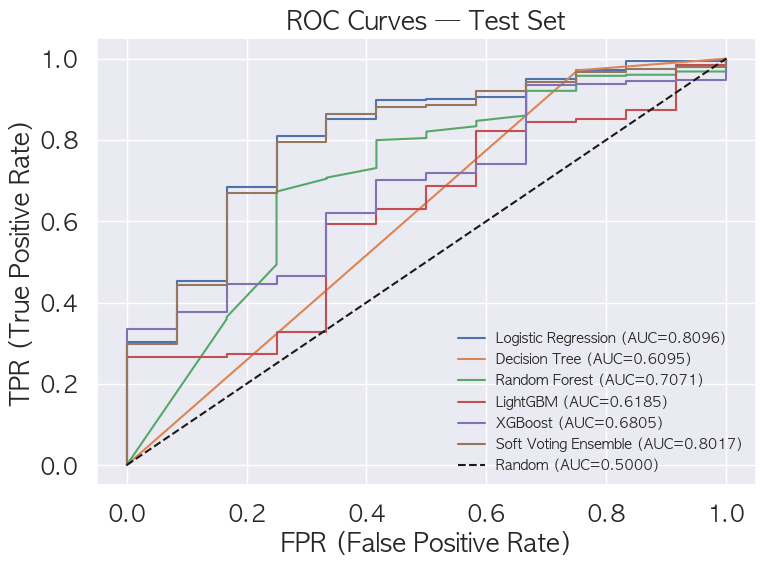

[저장] ../outputs/roc_curves.png


In [68]:
# ROC 커브 시각화 및 저장
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = {
    'Logistic Regression' : lr_test,
    'Decision Tree'       : dt_test,
    'Random Forest'       : rf_test,
    'LightGBM'            : lgb_test,
    'XGBoost'             : xgb_test,
    'Soft Voting Ensemble': ensemble_test,
}

for name, result in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={result["test_auc"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5000)')
ax.set_xlabel('FPR (False Positive Rate)')
ax.set_ylabel('TPR (True Positive Rate)')
ax.set_title('ROC Curves — Test Set')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] ../outputs/roc_curves.png')

---
## 10. 피처 중요도 재생성 (현재 6개 피처 기준)

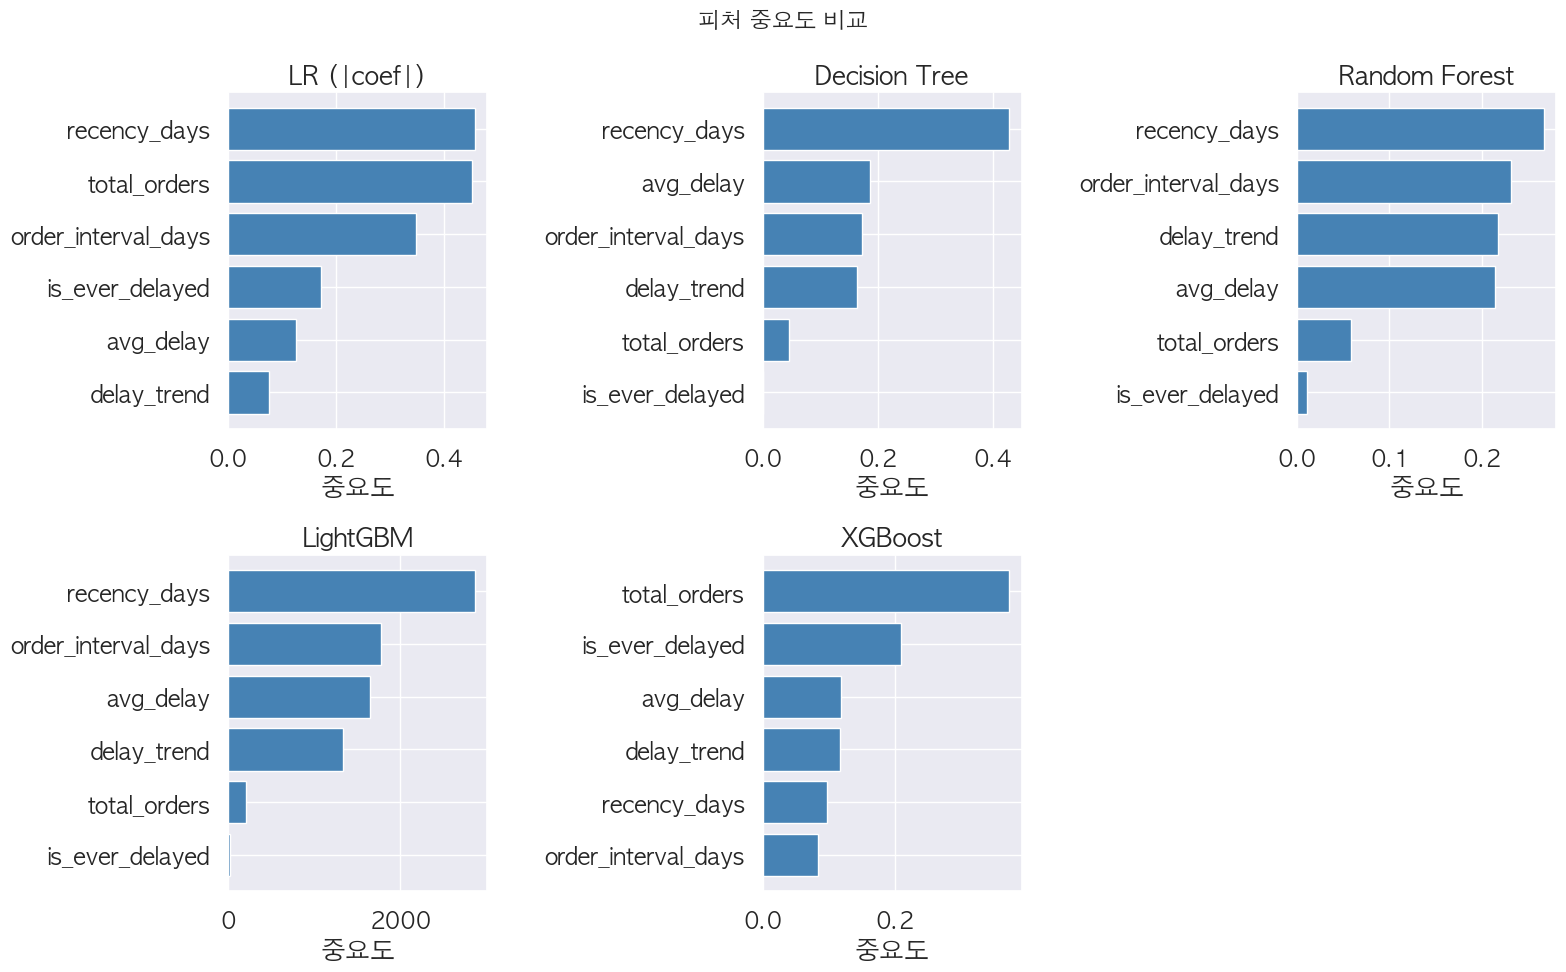

[저장] ../outputs/feature_importance.png
사용 피처: ['avg_delay', 'total_orders', 'is_ever_delayed', 'recency_days', 'delay_trend', 'order_interval_days']


In [69]:
importance_models = {
    'LR (|coef|)'  : np.abs(lr_pipe.named_steps['lr'].coef_[0]),
    'Decision Tree': dt_pipe.named_steps['dt'].feature_importances_,
    'Random Forest': rf_pipe.named_steps['rf'].feature_importances_,
    'LightGBM'     : lgb_pipe.named_steps['lgb'].feature_importances_,
    'XGBoost'      : xgb_pipe.named_steps['xgb'].feature_importances_,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (name, importances) in zip(axes_flat, importance_models.items()):
    indices = np.argsort(importances)
    ax.barh([feature_cols[i] for i in indices], importances[indices], color='steelblue')
    ax.set_title(name)
    ax.set_xlabel('중요도')

axes_flat[-1].set_visible(False)
fig.suptitle('피처 중요도 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] ../outputs/feature_importance.png')
print(f'사용 피처: {feature_cols}')